In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage import data, img_as_float
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_objects

In [57]:
def show_two(img1, img2, title1, title2, cmap1=None, cmap2=None):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap=cmap1)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap=cmap2)
    plt.title(title2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

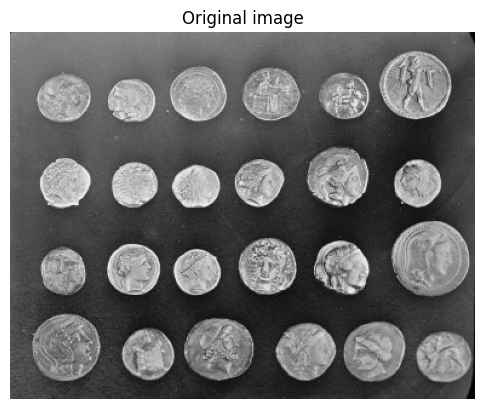

In [58]:
image = img_as_float(data.coins())

plt.figure(figsize=(6, 5))
plt.imshow(image, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

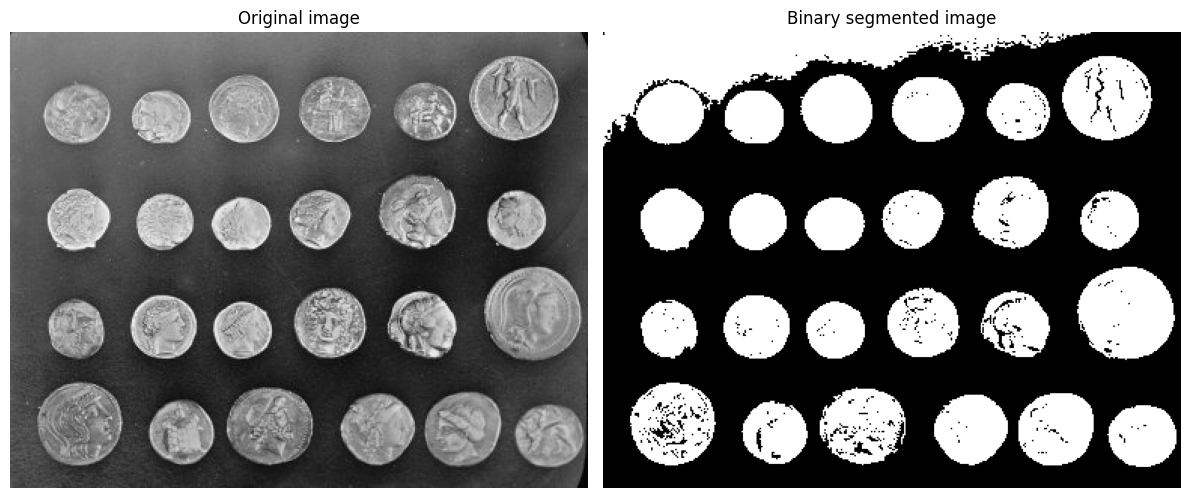

Threshold value: 0.4172564338235294


In [59]:
threshold = threshold_otsu(image)

binary = image > threshold

# heqim objekte shumë të vogla që janë zhurmë
binary_clean = remove_small_objects(binary, min_size=25)

show_two(
    image,
    binary_clean,
    "Original image",
    "Binary segmented image",
    cmap1="gray",
    cmap2="gray"
)

print("Threshold value:", threshold)

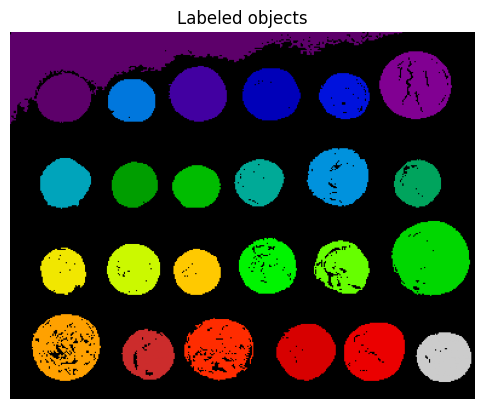

Number of detected objects: 24


In [60]:
labeled_image = label(binary_clean)

plt.figure(figsize=(6, 5))
plt.imshow(labeled_image, cmap="nipy_spectral")
plt.title("Labeled objects")
plt.axis("off")
plt.show()

print("Number of detected objects:", labeled_image.max())

In [61]:
properties = regionprops_table(
    labeled_image,
    properties=("label", "area", "eccentricity")
)

df = pd.DataFrame(properties)

df.head()

,label,area,eccentricity
0,1,9147.0,0.978666
1,2,2468.0,0.327227
2,3,1687.0,0.295960
3,4,1635.0,0.387259
4,5,1200.0,0.394199


In [62]:
df

,label,area,eccentricity
0,1,9147.0,0.978666
1,2,2468.0,0.327227
2,3,1687.0,0.295960
3,4,1635.0,0.387259
4,5,1200.0,0.394199
5,6,1135.0,0.424994
6,7,1838.0,0.371171
7,8,1327.0,0.341573
8,9,1204.0,0.377598
9,10,1134.0,0.331198


In [63]:
df_sorted = df.sort_values(by="area", ascending=False)

df_sorted.head(10)

,label,area,eccentricity
0,1,9147.0,0.978666
12,13,3063.0,0.304491
1,2,2468.0,0.327227
18,19,2124.0,0.236196
19,20,1983.0,0.422713
20,21,1925.0,0.426914
6,7,1838.0,0.371171
21,22,1730.0,0.332465
2,3,1687.0,0.295960
13,14,1642.0,0.302749


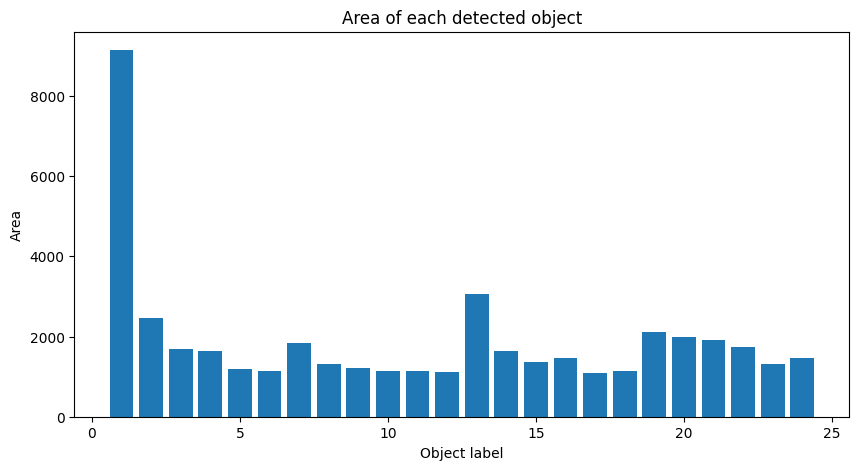

In [64]:
plt.figure(figsize=(10, 5))
plt.bar(df["label"], df["area"])
plt.xlabel("Object label")
plt.ylabel("Area")
plt.title("Area of each detected object")
plt.show()

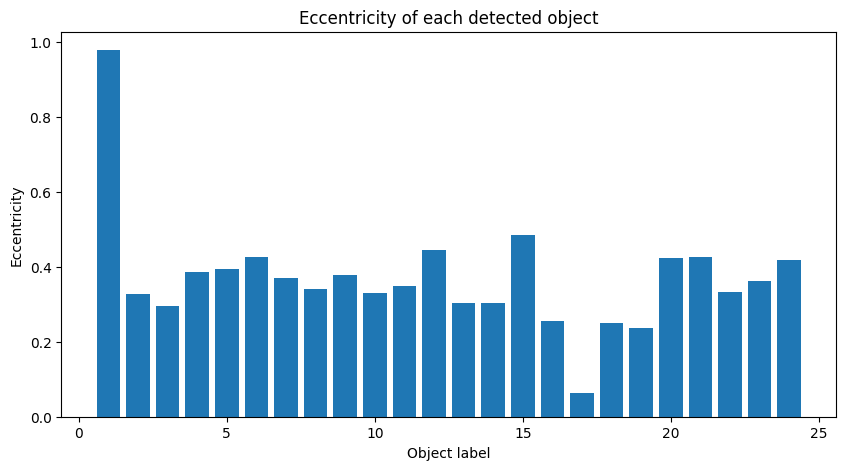

In [65]:
plt.figure(figsize=(10, 5))
plt.bar(df["label"], df["eccentricity"])
plt.xlabel("Object label")
plt.ylabel("Eccentricity")
plt.title("Eccentricity of each detected object")
plt.show()

In [66]:
print("""
In this exercise, the image was segmented using Otsu thresholding.
After segmentation, connected components were labeled as individual objects.
For each labeled object, two regional properties were extracted:

Area: number of pixels belonging to the object.
Eccentricity: measures how elongated the object is.

Objects with eccentricity close to 0 are more circular.
Objects with eccentricity close to 1 are more elongated.
""")


In this exercise, the image was segmented using Otsu thresholding.
After segmentation, connected components were labeled as individual objects.
For each labeled object, two regional properties were extracted:

Area: number of pixels belonging to the object.
Eccentricity: measures how elongated the object is.

Objects with eccentricity close to 0 are more circular.
Objects with eccentricity close to 1 are more elongated.

